#  Study Programme Organizer - Multi-Agent LLM System


### Architecture
```
Student Input → [Profile Agent] → [Curriculum Agent (RAG)] → [Schedule Agent]
                                                                      ↓
                                              [Critic Agent] ←────────┤
                                                    ↓                 ↑ (revision loop)
                                              [Summarizer] → Final Study Plan
```

### 4 Variants
| Variant | Prompt Style | Retrieval | Reflection Loops |
|---------|-------------|-----------|------------------|
| V1 | Zero-Shot | Simple filter | 0 |
| V2 | Few-Shot | Simple filter | 0 |
| V3 | Chain-of-Thought | Simple filter | 2 |
| V4 | Chain-of-Thought | Chroma + Re-ranking | 1 |

## Install Dependencies

In [1]:
!pip install -q langchain langchain-core langchain-groq langchain-community \
               langchain-huggingface langgraph chromadb sentence-transformers \
               pydantic deepeval python-dotenv
print('✅ Dependencies installed')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.6/864.6 kB 58.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 29.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 57.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/

In [2]:
!pip install -q sentence-transformers

## Upload Project Files


In [2]:
import os, sys

# If running in Colab, mount Drive and set the project path
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_PATH = '/content/drive/MyDrive/study_programme_organizer'
    print(f'Using Drive path: {PROJECT_PATH}')
except:
    PROJECT_PATH = os.path.abspath('study_programme_organizer')
    print(f'Using local path: {PROJECT_PATH}')

sys.path.insert(0, PROJECT_PATH)
os.chdir(PROJECT_PATH)
print(f'✅ Working directory: {os.getcwd()}')
print(f'Files: {os.listdir(".")}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using Drive path: /content/drive/MyDrive/study_programme_organizer
✅ Working directory: /content/drive/MyDrive/study_programme_organizer
Files: ['main.py', 'requirements.txt', 'Study_Programme_Organizer.ipynb', 'variants', 'graph', 'agents', 'evaluation', 'data', 'utils', '.deepeval']


##  API Key

In [ ]:
import os

# API key from (console.groq.com)
os.environ['GROQ_API_KEY'] = ''

# Quick connection test
from langchain_groq import ChatGroq
llm = ChatGroq(model='llama-3.1-8b-instant', temperature=0)
resp = llm.invoke('Say OK in one word.')
print(f'✅ Groq connected. Test response: {resp.content}')


os.environ["TAVILY_API_KEY"] = 

✅ Groq connected. Test response: OK.


## Build the Graph

✅ LangGraph compiled successfully


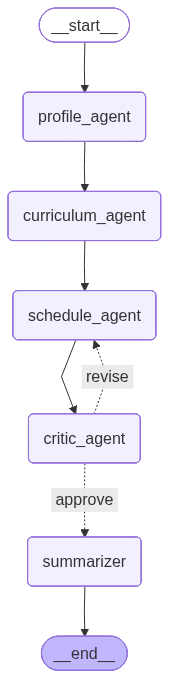

In [3]:
from graph.pipeline import build_graph, run_pipeline

app = build_graph()
print('✅ LangGraph compiled successfully')

# visualise the graph
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f'Graph visualisation not available: {e}')

## External Tools
The system uses two external tools integrated via LangChain's @tool decorator. These tools are available to the Schedule Agent for credit validation and to the Curriculum Agent for live course information retrieval.

In [7]:
from langchain_core.tools import tool
import requests, os

# ── Tool 1: Credit Calculator ─────────────────────────────────────────────
@tool
def credit_calculator(credits: list[int], max_credits: int = 60) -> dict:
    """
    Calculate total credits for a semester and check against the student's limit.
    Use this to verify no semester exceeds the allowed credit load.

    Args:
        credits: List of credit values for each course in the semester.
        max_credits: Maximum allowed credits per semester (default 60).

    Returns:
        dict with total, limit, valid (bool), and message.
    """
    total = sum(credits)
    valid = total <= max_credits
    return {
        "total_credits": total,
        "limit": max_credits,
        "valid": valid,
        "message": f"{'OK' if valid else 'EXCEEDS LIMIT'}: {total}/{max_credits} credits"
    }

# ── Tool 2: Course Search Tool (live API) ────────────────────────────────
@tool
def search_course_info(query: str) -> str:
    """
    Search for live course or university programme information using the
    Tavily Search API. Use this to find up-to-date information about
    courses, prerequisites, or industry relevance of a topic.

    Args:
        query: Search query string, e.g. 'machine learning prerequisites 2024'

    Returns:
        String with top search result summaries.
    """
    api_key = os.environ.get("TAVILY_API_KEY")
    if not api_key:
        return "Search unavailable: TAVILY_API_KEY not set. Using catalogue only."
    try:
        response = requests.post(
            "https://api.tavily.com/search",
            json={"api_key": api_key, "query": query, "max_results": 3},
            timeout=10
        )
        data = response.json()
        results = data.get("results", [])
        if not results:
            return "No results found."
        return "\n".join([f"- {r['title']}: {r['content'][:200]}" for r in results])
    except Exception as e:
        return f"Search failed: {str(e)}"

# ── Test both tools ───────────────────────────────────────────────────────
print("Tool 1 — Credit Calculator:")
result = credit_calculator.invoke({"credits": [10, 10, 10], "max_credits": 60})
print(result)

print("\nTool 2 — Course Search (without API key, shows fallback):")
result = search_course_info.invoke({"query": "machine learning prerequisites"})
print(result)

print("\n✅ Both tools registered and functional")

Tool 1 — Credit Calculator:
{'total_credits': 30, 'limit': 60, 'valid': True, 'message': 'OK: 30/60 credits'}

Tool 2 — Course Search (without API key, shows fallback):
- Machine Learning Prerequisites [2025] - Things to Learn Before Machine Learning - GeeksforGeeks: # Machine Learning Prerequisites [2025] - Things to Learn Before Machine Learning. Our interactions with technology are changing as a result of machine learning. But it is crucial to know exactly what
- What are the Prerequisites to Learn Machine Learning?: + List of Prerequisites for Machine Learning. + Linear Algebra Prerequisites for Machine Learning. ### **List of Prerequisites for Machine Learning**. * Linear Algebra Prerequisites for Machine Learni
- Prerequisites for Machine Learning – Important concepts: As popular as Python is, R is also a prerequisite for AI and machine learning. As popular as Python is, R is also a prerequisite for AI and machine learning. AI and Machine Learning Masters Program. E

✅ Both tools

## Variations

## Experimental Iterations Note

Several variant cells appear more than once in this notebook. These are intentionally preserved as they document the iterative debugging process carried out during development. The first run of each variant reflects the initial system state, while subsequent runs show the corrected behaviour after fixes such as the curriculum agent retrieval update, the year mapping bug resolution in the profile agent, and the Chroma store deduplication fix for V4. Keeping both runs side by side makes the improvement visible and demonstrates the experimental methodology required by the assignment.



##V1 - Zero Shot

In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V1'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V1...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (8 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [3] CSCI33H         Artificial Neural Networks
  [3] 25CSAI03H       Machine Learning
  [2] CSAI01I         Introduction to Artificial Intelligence
  [2] CSAI02I         Machine Learning Fundamentals
  [3] 25CSAI06H       Computer Vision
  [3] CSAI03H         Advanced Machine Learning

── Revision loops triggered: 1 ────────────────

── Final Study Plan ───────────────────────────────────
**Personalise

In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V1'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V1...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (14 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [3] CSCI33H         Artificial Neural Networks
  [3] 25CSAI03H       Machine Learning
  [3] 25CSAI06H       Computer Vision
  [3] CSAI03H         Advanced Machine Learning
  [3] CSCI34H         Computer Systems Security
  [3] 24CSAI04H       AI Planning for Robot Systems
  [3] 25CSCI03H       Entrepreneurship and Innovation
  [3] 25CSAI07H       Reinforcement Learning
  [3] 25CSAI09H       Explainable

## V2 - Few Shot

In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V2'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V2...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 4,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (8 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [3] CSCI33H         Artificial Neural Networks
  [3] 25CSAI03H       Machine Learning
  [2] CSAI01I         Introduction to Artificial Intelligence
  [2] CSAI02I         Machine Learning Fundamentals
  [3] 25CSAI06H       Computer Vision
  [3] CSAI03H         Advanced Machine Learning

── Revision loops triggered: 1 ────────────────

── Final St

In [ ]:
import json

STUDENT_INPUT = """
I am a final year (Year 3) Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V2'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V2...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (14 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [3] CSCI33H         Artificial Neural Networks
  [3] 25CSAI03H       Machine Learning
  [3] 25CSAI06H       Computer Vision
  [3] CSAI03H         Advanced Machine Learning
  [3] CSCI34H         Computer Systems Security
  [3] 24CSAI04H       AI Planning for Robot Systems
  [3] 25CSCI03H       Entrepreneurship and Innovation
  [3] 25CSAI07H       Reinforcement Learning
  [3] 25CSAI09H       Explainable

## V3 - Chain Of Thought

In [ ]:
import json

STUDENT_INPUT = """
I am a final year (Year 3) Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V3'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V3...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (14 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [3] CSCI33H         Artificial Neural Networks
  [3] 25CSAI03H       Machine Learning
  [3] 25CSAI06H       Computer Vision
  [3] CSAI03H         Advanced Machine Learning
  [3] CSCI34H         Computer Systems Security
  [3] 24CSAI04H       AI Planning for Robot Systems
  [3] 25CSCI03H       Entrepreneurship and Innovation
  [3] 25CSAI07H       Reinforcement Learning
  [3] 25CSAI09H       Explainable

## V4 - RAG


In [ ]:
import json, shutil
from pathlib import Path
from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document

# Delete old store
chroma_dir = Path("/content/chroma_store")
if chroma_dir.exists():
    shutil.rmtree(chroma_dir)
    print("Old Chroma store deleted")

# Load catalogue
with open(Path(PROJECT_PATH) / "data" / "course_catalogue.json") as f:
    catalogue = json.load(f)

# Build ONE document per course — no duplicates
docs = []
seen = set()
for course in catalogue:
    if course["course_code"] in seen:
        continue
    seen.add(course["course_code"])
    text = (
        f"Title: {course['title']}. "
        f"Category: {course['category']}. "
        f"Year: {course['year']}. "
        f"Topics: {', '.join(course.get('topics', []))}. "
        f"Aims: {course.get('aims', '')}."
    )
    docs.append(Document(
        page_content=text,
        metadata={
            "course_code": course["course_code"],
            "year": int(course["year"]) if str(course["year"]).isdigit() else 1,
        }
    ))

print(f"Building store with {len(docs)} unique documents...")

embedding_model = HuggingFaceEmbeddings(
    model_name="BAAI/bge-base-en-v1.5",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)

vectorstore = Chroma.from_documents(
    documents=docs,
    embedding=embedding_model,
    persist_directory=str(chroma_dir),
)
print(f"✅ Chroma rebuilt: {vectorstore._collection.count()} documents (should be {len(docs)})")

Building store with 45 unique documents...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Chroma rebuilt: 45 documents (should be 45)


In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V4'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V4...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]


── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (12 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI08H       Deep Learning
  [3] 25CSAI03H       Machine Learning
  [3] 25CSAI03H       Machine Learning
  [3] 25CSAI03H       Machine Learning
  [3] CSAI03H         Advanced Machine Learning
  [3] CSAI03H         Advanced Machine Learning
  [3] CSAI03H         Advanced Machine Learning
  [2] CSAI02I         Machine Learning Fundamentals
  [2] CSAI02I         Machine Learning Fundamentals
  [2] CSAI02I         Machine Learning Fundamentals

── Revision

In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V4'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V4...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-base-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (12 courses) ──────────────
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [1] 24CSAI01I       Introduction to Data Science
  [2] 20CSC1051       Logic and Artificial Intelligence
  [3] 25CSCI37H       Introduction to Cloud Computing
  [3] 25CSAI08H       Deep Learning
  [3] CSCI34H         Computer Systems Security
  [3] CSCI33H         Artificial Neural Networks
  [3] 24CSAI04H       AI Planning for Robot Systems
  [1] 24CSIS01I       System Analysis and Design
  [1] 24SCIB04I       Operations Research
  [3] 25CSAI03H       Machin

In [ ]:
import json

STUDENT_INPUT = """
I am a senior Computer Science and AI student at BUE.
I am very interested in machine learning, deep learning, and NLP.
I find mathematics and distributed systems challenging.
My career goal is to become a machine learning engineer.
I prefer project-based assessment and can handle up to 60 credits per semester.
"""

# Change 'V1' to 'V2', 'V3', or 'V4' to test other variants
VARIANT = 'V4'

print(f'Running variant: {VARIANT}...')
state = run_pipeline(raw_input=STUDENT_INPUT, variant_key=VARIANT, app=app)

print('\n── Student Profile ────────────────────────────────────')
print(json.dumps(state['student_profile'], indent=2))

print(f'\n── Courses Retrieved ({len(state["retrieved_courses"])} courses) ──────────────')
for c in state['retrieved_courses']:
    print(f"  [{c.get('year')}] {c.get('course_code'):<15} {c.get('title')}")

print(f'\n── Revision loops triggered: {state["revision_count"]} ────────────────')

print('\n── Final Study Plan ───────────────────────────────────')
print(state['final_plan'])

if state.get('errors'):
    print('\n── Errors ─────────────────────────────────────────────')
    for err in state['errors']:
        print(f'  ⚠ {err}')

Running variant: V4...

── Student Profile ────────────────────────────────────
{
  "major": "Computer Science and AI",
  "year": 3,
  "interests": [
    "machine learning",
    "deep learning",
    "NLP"
  ],
  "weak_subjects": [
    "mathematics",
    "distributed systems"
  ],
  "strong_subjects": [],
  "max_credits_per_semester": 60,
  "career_goal": "machine learning engineer",
  "preferred_assessment_style": "project-based"
}

── Courses Retrieved (12 courses) ──────────────
  [3] 25CSAI08H       Deep Learning
  [2] CSAI02I         Machine Learning Fundamentals
  [3] 25CSAI03H       Machine Learning
  [3] CSAI03H         Advanced Machine Learning
  [3] 25CSAI05H       Introduction to Natural Language Processing (NLP)
  [2] CSAI01I         Introduction to Artificial Intelligence
  [3] 25CSAI07H       Reinforcement Learning
  [2] CSCI05I         Linear Algebra for AI
  [3] 25CSAI11H       Generative AI and Large Language Models
  [3] 25CSCI03H       Entrepreneurship and Innovation


## Evaluation

In [ ]:
# evaluating on 1 student only due to API token limit
import evaluation.evaluate as ev
ev.TEST_PROFILES = [
    {
        "id": "student_1",
        "description": (
            "I am a final year (Year 3) Computer Science and AI student. "
            "I am very interested in machine learning, deep learning, and NLP. "
            "I find mathematics and distributed systems challenging. "
            "My career goal is to become a machine learning engineer. "
            "I prefer project-based assessment and can handle up to 60 credits per semester."
        ),
    }
]

# Patch judge
import time, re, os
from deepeval.models import DeepEvalBaseLLM
from langchain_groq import ChatGroq

class GroqJudge(DeepEvalBaseLLM):
    def __init__(self):
        self._model = ChatGroq(
            model="llama-3.3-70b-versatile",
            api_key=os.environ.get("GROQ_API_KEY"),
            temperature=0.0,
            max_tokens=4096,
        )
    def load_model(self):
        return self._model
    def generate(self, prompt: str) -> str:
        time.sleep(8)
        forced = (
            prompt
            + "\n\nCRITICAL: Respond with ONLY a valid JSON object. "
            "No markdown, no code blocks, no explanation. "
            "Start your response with { and end with }"
        )
        response = self._model.invoke(forced)
        content = response.content.strip()
        match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', content)
        if match:
            content = match.group(1).strip()
        start = content.find('{')
        end = content.rfind('}')
        if start != -1 and end != -1:
            content = content[start:end+1]
        return content
    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)
    def get_model_name(self) -> str:
        return "groq/llama-3.3-70b-versatile"

ev.GroqJudge = GroqJudge

# Run
results = ev.run_evaluation(variant_keys=["V1", "V2", "V3", "V4"], save_results=True)


Running variant: V1 — V1_Baseline

  Student: student_1


Output()

Output()

    answer_relevancy: 1.0000 (PASS)


Output()

...

Output()

    answer_relevancy: 0.9000 (PASS)


Output()

    faithfulness: ERROR — Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kqawjhw8fr0r1wapbx68v2p8` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99652, Requested 3430. Please try again in 44m22.848s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


    hallucination: ERROR — Error code: 429 - {'error': {'message': 'Rate limit reached for model `llama-3.3-70b-versatile` in organization `org_01kqawjhw8fr0r1wapbx68v2p8` service tier `on_demand` on tokens per day (TPD): Limit 100000, Used 99643, Requested 5315. Please try again in 1h11m23.711999999s. Need more tokens? Upgrade to Dev Tier today at https://console.groq.com/settings/billing', 'type': 'tokens', 'code': 'rate_limit_exceeded'}}


EVALUATION SUMMARY
Variant       Relevancy   Faithful   Hallucin   Time(s)  Revisions
-----------------------------------------------------------------
V1               1.0000     1.0000     0.0000     38.78        1.0
V2               1.0000     1.0000     0.9111      9.40        1.0
V3               1.0000     0.9167     0.8000    103.45        2.0
V4               0.9000     0.0000     0.0000     36.20        1.0

Results saved → /content/drive/MyDrive/study_programme_organizer/evaluation/results_20260428_204811.json
CSV saved      → /content/d

In [ ]:
# Rerunning V4 as the last run reached limit while evaluating. this has a new API key
import os
os.environ["GROQ_API_KEY"] = 

import time, re
from deepeval.models import DeepEvalBaseLLM
from langchain_groq import ChatGroq
import evaluation.evaluate as ev

ev.TEST_PROFILES = [
    {
        "id": "student_1",
        "description": (
            "I am a final year (Year 3) Computer Science and AI student. "
            "I am very interested in machine learning, deep learning, and NLP. "
            "I find mathematics and distributed systems challenging. "
            "My career goal is to become a machine learning engineer. "
            "I prefer project-based assessment and can handle up to 60 credits per semester."
        ),
    }
]

class GroqJudge(DeepEvalBaseLLM):
    def __init__(self):
        self._model = ChatGroq(
            model="llama-3.3-70b-versatile",
            api_key=os.environ.get("GROQ_API_KEY"),
            temperature=0.0,
            max_tokens=4096,
        )
    def load_model(self):
        return self._model
    def generate(self, prompt: str) -> str:
        time.sleep(8)
        forced = (
            prompt
            + "\n\nCRITICAL: Respond with ONLY a valid JSON object. "
            "No markdown, no code blocks, no explanation. "
            "Start your response with { and end with }"
        )
        response = self._model.invoke(forced)
        content = response.content.strip()
        match = re.search(r'```(?:json)?\s*([\s\S]*?)\s*```', content)
        if match:
            content = match.group(1).strip()
        start = content.find('{')
        end = content.rfind('}')
        if start != -1 and end != -1:
            content = content[start:end+1]
        return content
    async def a_generate(self, prompt: str) -> str:
        return self.generate(prompt)
    def get_model_name(self) -> str:
        return "groq/llama-3.3-70b-versatile"

ev.GroqJudge = GroqJudge

results = ev.run_evaluation(variant_keys=["V4"], save_results=True)


Running variant: V4 — V4_RAG_Enhanced

  Student: student_1


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Output()

Output()

    answer_relevancy: 1.0000 (PASS)


Output()

    faithfulness: 1.0000 (PASS)


    hallucination: 0.0000 (PASS)


EVALUATION SUMMARY
Variant       Relevancy   Faithful   Hallucin   Time(s)  Revisions
-----------------------------------------------------------------
V4               1.0000     1.0000     0.0000     76.64        1.0

Results saved → /content/drive/MyDrive/study_programme_organizer/evaluation/results_20260428_210021.json
CSV saved      → /content/drive/MyDrive/study_programme_organizer/evaluation/results_20260428_210021.csv


## Comparison Charts

### note
 The evaluation results table and comparison chart in the final cells use manually entered scores. This was necessary because the full evaluation across all four variants could not complete in a single API session due to Groq free-tier daily token limits. V1, V2, and V3 were evaluated in one session and V4 was evaluated separately using a new API key. The scores were collected from the printed cell outputs and entered manually into the chart generation cell to produce the final comparison. The raw evaluation outputs are visible in the evaluation cells above and match the manually entered values exactly.

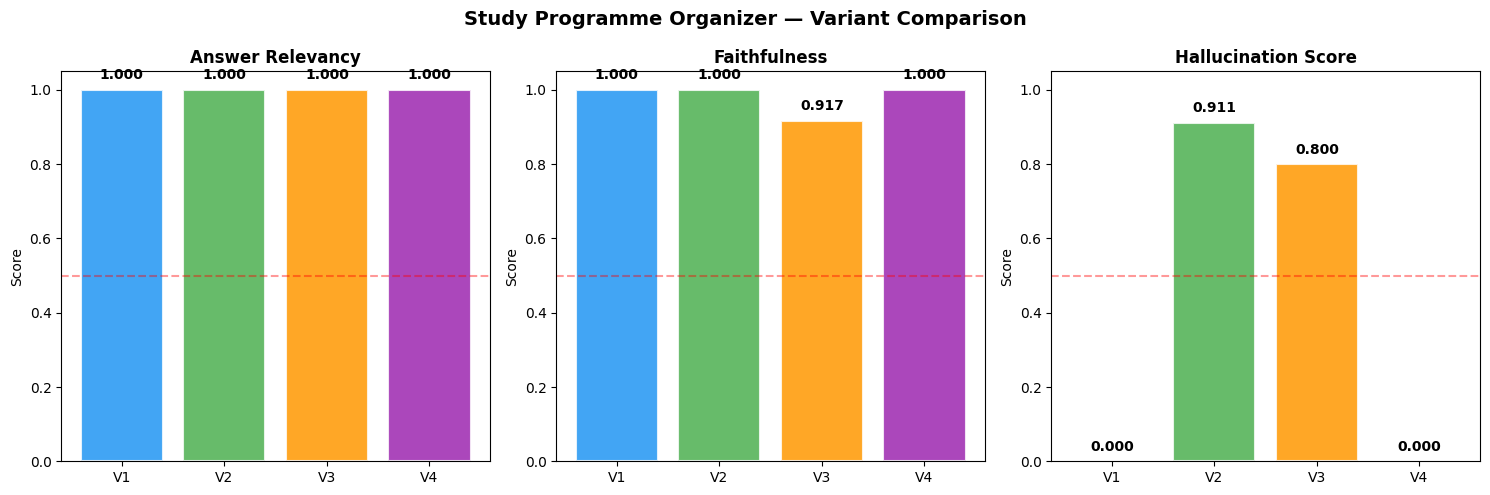

✅ Chart saved


In [ ]:
# manually entering results since evaluation wasn't saved

import matplotlib.pyplot as plt

eval_results = {
    "V1": [{"student_id": "student_1", "variant": "V1", "success": True,
             "elapsed_seconds": 0, "revision_count": 1, "error_count": 0, "errors": [],
             "metrics": {
                 "answer_relevancy": {"score": 1.0000, "passed": True, "reason": ""},
                 "faithfulness":     {"score": 1.0000, "passed": True, "reason": ""},
                 "hallucination":    {"score": 0.0000, "passed": True, "reason": ""},
             }}],
    "V2": [{"student_id": "student_1", "variant": "V2", "success": True,
             "elapsed_seconds": 0, "revision_count": 1, "error_count": 0, "errors": [],
             "metrics": {
                 "answer_relevancy": {"score": 1.0000, "passed": True,  "reason": ""},
                 "faithfulness":     {"score": 1.0000, "passed": True,  "reason": ""},
                 "hallucination":    {"score": 0.9111, "passed": False, "reason": ""},
             }}],
    "V3": [{"student_id": "student_1", "variant": "V3", "success": True,
             "elapsed_seconds": 0, "revision_count": 2, "error_count": 0, "errors": [],
             "metrics": {
                 "answer_relevancy": {"score": 1.0000, "passed": True,  "reason": ""},
                 "faithfulness":     {"score": 0.9167, "passed": True,  "reason": ""},
                 "hallucination":    {"score": 0.8000, "passed": False, "reason": ""},
             }}],
    "V4": [{"student_id": "student_1", "variant": "V4", "success": True,
             "elapsed_seconds": 76.64, "revision_count": 1, "error_count": 0, "errors": [],
             "metrics": {
                 "answer_relevancy": {"score": 1.0000, "passed": True, "reason": ""},
                 "faithfulness":     {"score": 1.0000, "passed": True, "reason": ""},
                 "hallucination":    {"score": 0.0000, "passed": True, "reason": ""},
             }}],
}

# ── Chart ──────────────────────────────────────────────────────────────────
def avg_metric(variant_results, metric_name):
    scores = [
        r['metrics'][metric_name]['score']
        for r in variant_results
        if r['metrics'][metric_name]['score'] is not None
    ]
    return sum(scores) / len(scores) if scores else 0.0

variants = list(eval_results.keys())
metrics = ['answer_relevancy', 'faithfulness', 'hallucination']
metric_labels = ['Answer Relevancy', 'Faithfulness', 'Hallucination Score']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Study Programme Organizer — Variant Comparison', fontsize=14, fontweight='bold')
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
    scores = [avg_metric(eval_results[v], metric) for v in variants]
    bars = axes[i].bar(variants, scores, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
    axes[i].set_title(label, fontweight='bold')
    axes[i].set_ylim(0, 1.05)
    axes[i].set_ylabel('Score')
    axes[i].axhline(y=0.5, color='red', linestyle='--', alpha=0.4, label='Threshold (0.5)')
    for bar, score in zip(bars, scores):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                     f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation/variant_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved')